In [63]:
import keras
import tensorflow as tf
import matplotlib.pyplot as plt, numpy as np

from sklearn.model_selection import train_test_split

import platform

# 한글 폰트 설정
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

# 마이너스 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

In [64]:
(train_input, train_target), (test_input, test_target) = \
    keras.datasets.fashion_mnist.load_data()


print(train_input.shape)
print(train_target.shape)

(60000, 28, 28)
(60000,)


In [65]:
train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0
test_scaled = test_input.reshape(-1, 28, 28, 1) / 255.0

In [66]:
train_scaled.shape, test_scaled.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

In [67]:
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)

In [68]:
model = keras.Sequential([
    keras.layers.Input(shape=(28,28,1)),
    keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(2),
    keras.layers.Flatten(),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(10, activation='softmax')
])

In [69]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [70]:
model.compile(
    optimizer='adam',
    loss=keras.losses.sparse_categorical_crossentropy,
    metrics=['accuracy']
)

In [71]:
checkpoint = keras.callbacks.ModelCheckpoint('best-model.keras', save_best_only=True)
early_stopping = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

In [72]:
history = model.fit(train_scaled, train_target,
                    epochs=20, validation_data=(val_scaled, val_target),
                    callbacks=[checkpoint, early_stopping])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8125 - loss: 0.5251 - val_accuracy: 0.8795 - val_loss: 0.3258
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8761 - loss: 0.3482 - val_accuracy: 0.8836 - val_loss: 0.3116
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8900 - loss: 0.3036 - val_accuracy: 0.9043 - val_loss: 0.2564
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9029 - loss: 0.2681 - val_accuracy: 0.9068 - val_loss: 0.2481
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9115 - loss: 0.2418 - val_accuracy: 0.9129 - val_loss: 0.2466
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9180 - loss: 0.2247 - val_accuracy: 0.9136 - val_loss: 0.2324
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9231 - loss: 0.2114 - val_accuracy: 0.9192 - val_loss: 0.2235
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9278 - loss: 0.1954 - 

In [73]:
print("조기 종료 epoch:", early_stopping.stopped_epoch)
print("최고 검증 정확도:", max(history.history["val_accuracy"]))
print("최저 검증 손실:", min(history.history["val_loss"]))

조기 종료 epoch: 8
최고 검증 정확도: 0.9191666841506958
최저 검증 손실: 0.2235163152217865


In [74]:
model = keras.models.load_model('best-model.keras')

In [75]:
model.layers

[<Conv2D name=conv2d_8, built=True>,
 <MaxPooling2D name=max_pooling2d_6, built=True>,
 <Conv2D name=conv2d_9, built=True>,
 <MaxPooling2D name=max_pooling2d_7, built=True>,
 <Flatten name=flatten_3, built=True>,
 <Dense name=dense_14, built=True>,
 <Dropout name=dropout_3, built=True>,
 <Dense name=dense_15, built=True>]

In [76]:
type(model.layers)

list

In [77]:
conv = model.layers[0]

In [78]:
conv.weights[0].shape

TensorShape([3, 3, 1, 32])

In [79]:
conv.weights[1].shape

TensorShape([32])

In [80]:
conv_weights = conv.weights[0].numpy()

In [81]:
conv_weights.mean(), conv_weights.std()

(np.float32(-0.015247228), np.float32(0.22443365))

In [82]:
# 학습 X 모델
no_train_model = keras.Sequential()
no_train_model.add(keras.layers.Input(shape=(28,28,1)))
no_train_model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'))

In [83]:
no_train_conv = no_train_model.layers[0]
no_train_weights = no_train_conv.weights[0].numpy()
no_train_weights.mean(), no_train_weights.std()

(np.float32(-0.00084647245), np.float32(0.07939516))

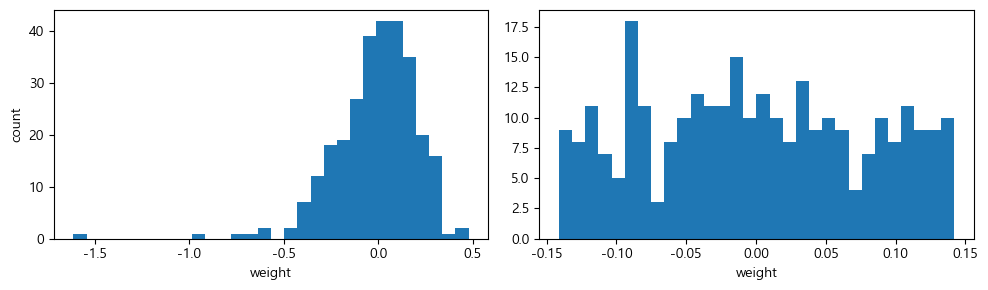

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].hist(conv_weights.reshape(-1), bins=30)
axes[0].set_xlabel("weight")
axes[0].set_ylabel("count")

axes[1].hist(no_train_weights.reshape(-1), bins=30)
axes[1].set_xlabel("weight")

plt.tight_layout()
plt.show()

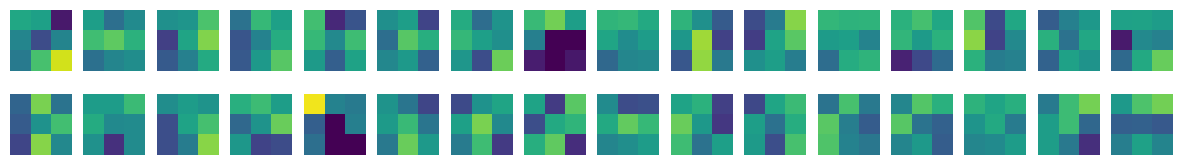

In [85]:
# 32개의 필터를 그리드로 출력(학습 후)
fig, axs = plt.subplots(2, 16, figsize=(15, 2))
for i in range(2):
    for j in range(16):
        axs[i, j].imshow(conv_weights[:, :, 0, i * 16 + j], vmin=-0.5, vmax=0.5)
        axs[i, j].axis("off")
plt.show()

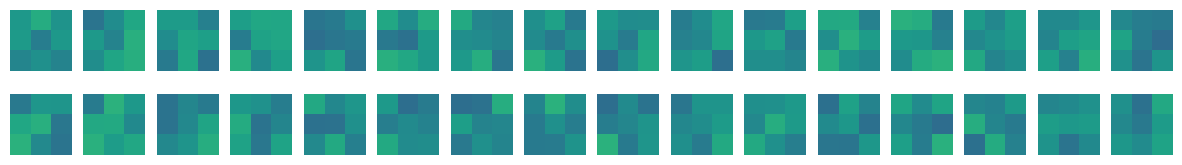

In [86]:
# 32개의 필터를 그리드로 출력(학습 전)
fig, axs = plt.subplots(2, 16, figsize=(15, 2))
for i in range(2):
    for j in range(16):
        axs[i, j].imshow(no_train_weights[:, :, 0, i * 16 + j], vmin=-0.5, vmax=0.5)
        axs[i, j].axis("off")
plt.show()


---
### 함수형 API

In [87]:
model_seq = keras.Sequential([
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

In [88]:
inputs = keras.Input(shape=(784,))
dense1 = keras.layers.Dense(100, activation="relu")
dense2 = keras.layers.Dense(10, activation="softmax")

hidden = dense1(inputs)
outputs = dense2(hidden)

func_model = keras.Model(inputs, outputs)

In [89]:
model.inputs[0], model.layers[0].output

(<KerasTensor shape=(None, 28, 28, 1), dtype=float32, sparse=False, ragged=False, name=input_layer_9>,
 <KerasTensor shape=(None, 28, 28, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor_132>)

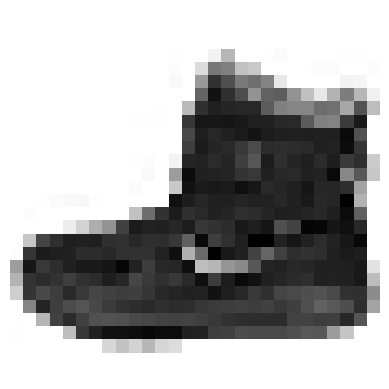

In [90]:
plt.imshow(train_input[0], cmap="gray_r")
plt.axis("off")
plt.show()

ankle_boot = train_input[0:1].reshape(-1, 28, 28, 1) / 255.0

In [91]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,580 (3.82 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 667,054 (2.54 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1번째 층 출력 크기: (1, 28, 28, 32)


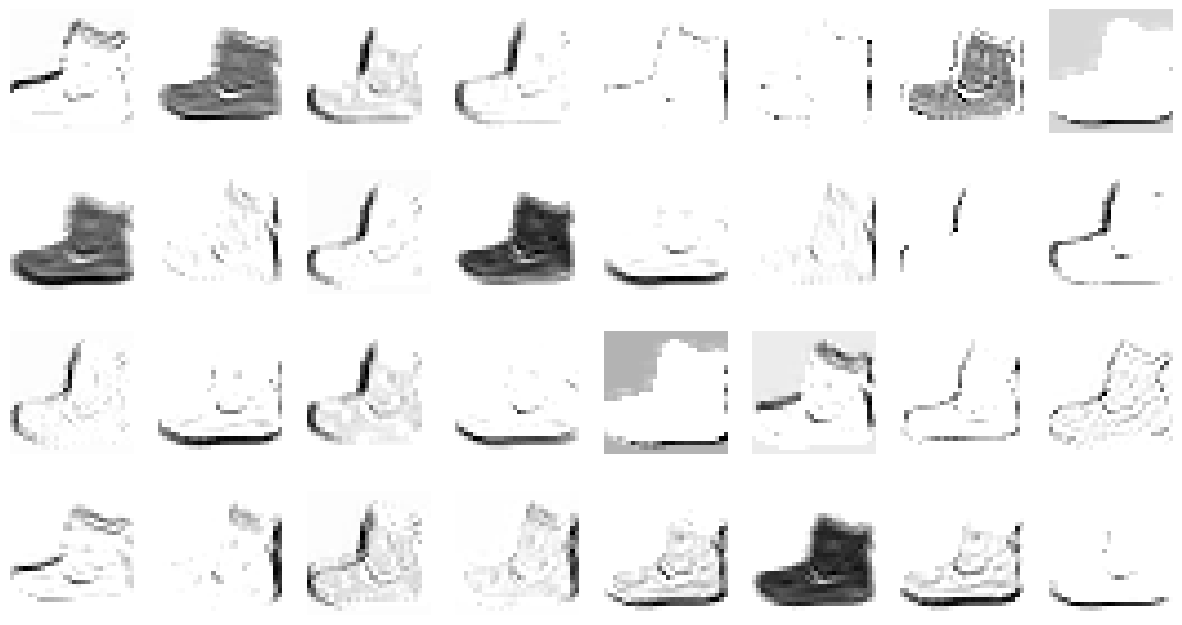

In [92]:
# 2. 1번째 Conv 층 활성화 모델 정의 및 예측
conv1_acti = keras.Model(inputs=model.inputs, outputs=model.layers[0].output)
feature_maps1 = conv1_acti.predict(ankle_boot)

print("1번째 층 출력 크기:", feature_maps1.shape)  # (1, 28, 28, 32)


# 3. 4행 8열(32장) 그리드 출력
fig, axs = plt.subplots(4, 8, figsize=(15, 8))
for i in range(4):
    for j in range(8):
        axs[i, j].imshow(feature_maps1[0, :, :, i * 8 + j], cmap="gray_r")
        axs[i, j].axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
2번째 층 출력 크기: (1, 14, 14, 64)


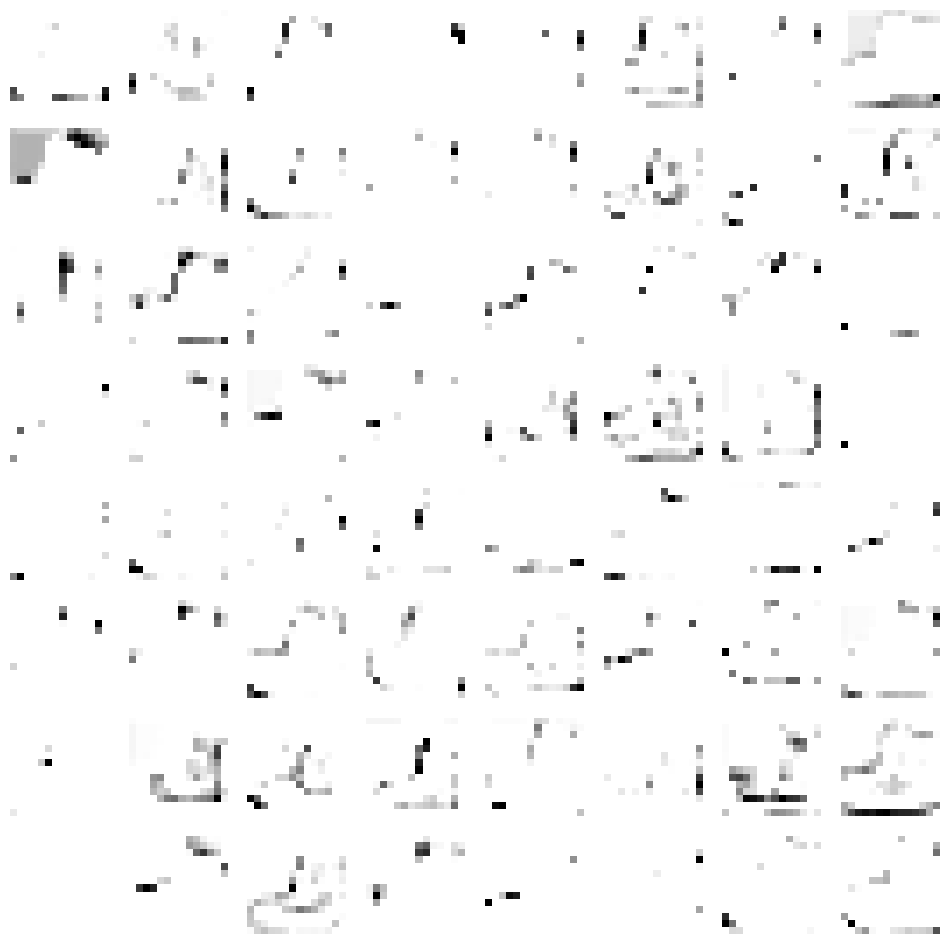

In [93]:
# 1. 2번째 Conv 층 활성화 모델 정의 및 예측 (인덱스 2번은 MaxPooling을 건너뛰기 위함)
conv2_acti = keras.Model(inputs=model.inputs, outputs=model.layers[2].output)
feature_maps2 = conv2_acti.predict(ankle_boot)

print("2번째 층 출력 크기:", feature_maps2.shape)  # (1, 14, 14, 64)

# 2. 8행 8열(64장) 그리드 출력
fig, axs = plt.subplots(8, 8, figsize=(12, 12))
for i in range(8):
    for j in range(8):
        axs[i, j].imshow(feature_maps2[0, :, :, i * 8 + j], cmap="gray_r")
        axs[i, j].axis("off")
plt.show()


---
### 데이터 증강

In [94]:
data_aug = keras.Sequential([
    keras.layers.RandomFlip('horizontal'),
    keras.layers.RandomRotation(0.1,),
    keras.layers.RandomZoom(0.1)
])

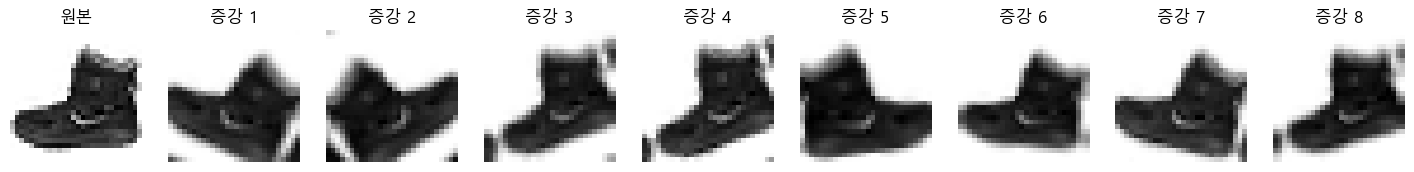

In [95]:
from keras.datasets import fashion_mnist

(train_input, _), _ = fashion_mnist.load_data()
sample = train_input[0:1].reshape(-1, 28, 28, 1) / 255.0  # ankle boot 1장

fig, axs = plt.subplots(1, 9, figsize=(18, 2))
axs[0].imshow(sample[0, :, :, 0], cmap="gray_r")
axs[0].set_title("원본")
axs[0].axis("off")

for i in range(1, 9):
    augmented = data_aug(sample, training=True)  # training=True: 변형 적용
    axs[i].imshow(augmented[0, :, :, 0], cmap="gray_r")
    axs[i].set_title(f"증강 {i}")
    axs[i].axis("off")
plt.show()

In [96]:
model_aug = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),
    data_aug,  # 입력 층 후 증강층 추가
    keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(64, 3, activation="relu", padding="same"),
    keras.layers.MaxPooling2D(2),
    keras.layers.Flatten(),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(10, activation="softmax"),
])

In [97]:
model_aug.compile(
    optimizer='adam',
    loss=keras.losses.sparse_categorical_crossentropy,
    metrics=['accuracy']
)

In [99]:
checkpoint_aug = keras.callbacks.ModelCheckpoint(
    "best-model-aug.keras", save_best_only=True
)

early_stopping_aug = keras.callbacks.EarlyStopping(
    patience=2, restore_best_weights=True
)

In [100]:
history_aug = model_aug.fit(
    train_scaled, train_target,
    epochs=10, validation_data=(val_scaled, val_target)
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8659 - loss: 0.3671 - val_accuracy: 0.8745 - val_loss: 0.3333
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8677 - loss: 0.3589 - val_accuracy: 0.8848 - val_loss: 0.3174
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8711 - loss: 0.3550 - val_accuracy: 0.8888 - val_loss: 0.3079
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8731 - loss: 0.3492 - val_accuracy: 0.8713 - val_loss: 0.3561
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8740 - loss: 0.3435 - val_accuracy: 0.8865 - val_loss: 0.3163
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8771 - loss: 0.3379 - val_accuracy: 0.8849 - val_loss: 0.3245
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8783 - loss: 0.3371 - val_accuracy: 0.8870 - val_loss: 0.3141
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8770 - loss: 0.